In [507]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import image, bar, circled_image
import urllib.request
import matplotlib.image as mpimg
from matplotlib.font_manager import FontProperties
from StatzFunctions import *
# Specify your font
regular = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Regular.ttf")  # Update the path to where the font is installed on your system
light = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Light.ttf")  # Update the path to where the font is installed on your system
bold = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Bold.ttf")  # Update the path to where the font is installed on your system

In [508]:
stat = 'Fouls'
stat_name_shortened = 'Fouls'
percent_columns = [1,2]
opp_badge = False
league = 'Serie A'
league_short = 'Serie A'
GW = 'GW38'
date = '2025-05-23'

In [509]:
teams = pd.read_csv(r"C:\Users\George\Documents\Statz.ai\Data\teams.csv")
players = pd.read_csv(r"C:\Users\George\Documents\Statz.ai\Data\players.csv")

In [510]:
projections = pd.read_excel(rf"C:\Users\George\Documents\Statz.ai\Data\Projections Output\{league}\Player Projections\PP {date}.xlsx")

In [511]:
injured_player_list = [
    'Oihan Sancet', 'Jhon Durán',
    'Mario Lemina', 'Kai Havertz', 'Hugo Duro', 'Josh Maja','Kalvin Phillips',
    'Dominic Calvert-Lewin', 'Kenny Tete','Marcus Rashford','Nicolas Jackson',
    'Charlie McNeill', 'Milan Aleksić', 'Isaak Davies', 'Lewis Koumas', 'Largie Ramazani',
    'Pau Víctor','Endrick','Sammie Szmodics','Edward Nketiah','Kiernan Dewsbury-Hall','Rio Ngumoha',
    'Sergio Reguilón','Justin Devenny','George Hirst',
    'Marko Arnautović','Ferran Torres','Ângelo','Adam Lallana','Tyler Morton',
    'Edmond-Paris Maghoma','Gabriel Jesus','Ansu Fati','Raheem Sterling','Kieran Tierney','Fabio Carvalho',
    'Cristhian Stuani','Vinícius Júnior','Thierno Barry','Luís Henriques de Barros Lopes','Akor Adams',
    'Kike Barja','Randy Nteka','Pol Lozano','Iker Muñoz','Ryan Yates','Eiran Joe Cashin','Ayoze Pérez',
    'Santiago Giménez', 'Giacomo Raspadori', 'Gianluca Scamacca', 'Maxwel Cornet','Tammy Abraham','Thijs Dallinga',
    'Vitinha','Alberto Baio', 'Devyne Rensch', 'Emerson Royal', 'Hamza Rafia']

projections = projections[~projections['Player'].isin(injured_player_list)]

In [512]:
def get_poisson_probs(projections, stat, numbers):
    df = projections[projections.columns[:5].tolist() + [stat]]
    df = df.sort_values(stat, ascending=False).head(10).reset_index(drop=True)
    probs = []
    for value in df[stat]:
        poisson_pred = poisson.pmf(np.arange(0, numbers.max()), value)
        for number in numbers:
            prob = (format(1 - poisson_pred[:number].sum().round(2), '.0%'))
            if prob == '100%':
                prob = '99%'
            probs.append(prob)
    for i in range(len(numbers)):
        df[f'{numbers[i]}+'] = probs[i::len(numbers)]
    return df

In [513]:
df = get_poisson_probs(projections, stat, np.array(percent_columns))

In [514]:
df

,Player,Position,Team,Opponent,Venue,Fouls,1+,2+
0,Koni De Winter,DEF,Genoa,Bologna,A,3.34,96%,85%
1,Denzel Dumfries,DEF,Inter,Como,A,3.01,95%,80%
2,Morten Thorsby,MID,Genoa,Bologna,A,2.70,93%,75%
3,Davide Faraoni,DEF,Hellas Verona,Empoli,A,2.32,90%,67%
4,Patrizio Masini,MID,Genoa,Bologna,A,2.32,90%,67%
5,Armando Izzo,DEF,Monza,Milan,A,2.30,90%,67%
6,Lorenzo Lucca,FWD,Udinese,Fiorentina,H,2.29,90%,67%
7,Liam Henderson,FWD,Empoli,Hellas Verona,H,2.26,90%,66%
8,Morten Frendrup,MID,Genoa,Bologna,A,2.25,89%,66%
9,Leonardo Pavoletti,FWD,Cagliari,Napoli,A,2.22,89%,65%


In [515]:
def get_images(df):
    team_badge = []
    opponent_badge = []
    player_img = []
    for player, team, opponent in df[['Player','Team','Opponent']].values:
        team_badge.append(teams[teams['name'] == team]['badge'].values[0])
        opponent_badge.append(teams[teams['name'] == opponent]['badge'].values[0])
        team_players = players[players['current_team_id'] == get_team_id(team)]
        player_img.append(team_players[team_players['display_name'] == player]['image'].values[0])
    df['Team Badge'] = team_badge
    df['Opponent Badge'] = opponent_badge
    df['Player Image'] = player_img
    return df

In [516]:
df = get_images(df)

In [517]:
# SHORTEN NAMES
for i in range(len(df)):
    if len(df.iloc[i]['Player'].split(' ')) > 2:
        df.at[i, 'Player'] = df.iloc[i]['Player'].split(' ')[1] + ' ' + df.iloc[i]['Player'].split(' ')[2]
    elif len(df.iloc[i]['Player'].split(' ')) > 1:
        df.at[i, 'Player'] = df.iloc[i]['Player'].split(' ')[1]
    else:
        df.at[i, 'Player'] = df.iloc[i]['Player'].split(' ')[0]

In [518]:
df['Bar'] = df[stat]

In [519]:
def convert_images(df):
    player_image_path = []
    team_badge_path = []
    opp_badge_path = []
    for i in range(len(df)):
        urllib.request.urlretrieve(df.iloc[i]['Player Image'], rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.png")
        try:
            mpimg.imread(rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.png")
            player_image_path.append(rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.png")
        except:
            Image.open(rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.png").save(rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.jpg")
            player_image_path.append(rf"C:\Users\George\Documents\Statz.ai\Images\Players\{df.iloc[i]['Player']}.jpg")
        urllib.request.urlretrieve(df.iloc[i]['Team Badge'], rf"C:\Users\George\Documents\Statz.ai\Images\Teams\{df.iloc[i]['Team']}.png")
        team_badge_path.append(rf"C:\Users\George\Documents\Statz.ai\Images\Teams\{df.iloc[i]['Team']}.png")
        urllib.request.urlretrieve(df.iloc[i]['Opponent Badge'], rf"C:\Users\George\Documents\Statz.ai\Images\Teams\{df.iloc[i]['Opponent']}.png")
        opp_badge_path.append(rf"C:\Users\George\Documents\Statz.ai\Images\Teams\{df.iloc[i]['Opponent']}.png")
    df['Player Image'] = player_image_path
    df['Team Badge'] = team_badge_path
    df['Opponent Badge'] = opp_badge_path
    return df

In [520]:
df = convert_images(df)

In [521]:
class MissingDict(dict):
    __missing__ = lambda self, key: key

map_values = {'Bayer 04 Leverkusen': 'LEV', 'Borussia Dortmund': 'BVB', 'Borussia Mönchengladbach': 'BMG', 'Holstein Kiel': 'HOL', 'Eintracht Frankfurt': 'EIN', 'FC Augsburg': 'AUG', 'FC Bayern München': 'BAY', 'FC Union Berlin': 'BER', 'FSV Mainz 05': 'MAI', 'Heidenheim': 'HEI', 'RB Leipzig': 'RBL', 'SC Freiburg': 'FRE', 'St. Pauli': 'PAU', 'TSG Hoffenheim': 'HOF', 'VfB Stuttgart': 'STU', 'VfL Bochum 1848': 'BOC', 'VfL Wolfsburg': 'WOL', 'Werder Bremen': 'WER', 'Blackburn Rovers': 'BLA', 'Bristol City': 'BRI', 'Burnley': 'BUR', 'Cardiff City': 'CAR', 'Coventry City': 'COV', 'Derby County': 'DER', 'Hull City': 'HUL', 'Leeds United': 'LEE', 'Luton Town': 'LUT', 'Middlesbrough': 'MID', 'Millwall': 'MIL', 'Norwich City': 'NOR', 'Oxford United': 'OXF', 'Plymouth Argyle': 'PLY', 'Portsmouth': 'POR', 'Preston North End': 'PRE', 'Queens Park Rangers': 'QPR', 'Sheffield United': 'SHU', 'Sheffield Wednesday': 'SHW', 'Stoke City': 'STO', 'Sunderland': 'SUN', 'Swansea City': 'SWA', 'Watford': 'WAT', 'West Bromwich Albion': 'WBA', 'Athletic Club': 'ATH', 'Atlético Madrid': 'ATL', 'Celta de Vigo': 'CEL', 'Deportivo Alavés': 'DEP', 'Espanyol': 'ESP', 'FC Barcelona': 'BAR', 'Getafe': 'GET', 'Girona': 'GIR', 'Las Palmas': 'PAL', 'Leganés': 'LEG', 'Mallorca': 'MAL', 'Osasuna': 'OSA', 'Rayo Vallecano': 'RAY', 'Real Betis': 'BET', 'Real Madrid': 'MAD', 'Real Sociedad': 'SOC', 'Real Valladolid': 'RVA', 'Sevilla': 'SEV', 'Valencia': 'VAL', 'Villarreal': 'VIL', 'Angers SCO': 'ANG', 'Auxerre': 'AUX', 'Brest': 'BRE', 'Le Havre': 'HAV', 'Lens': 'LEN', 'LOSC Lille': 'LIL', 'Monaco': 'MON', 'Montpellier': 'MON', 'Nantes': 'NAN', 'Nice': 'NIC', 'Olympique Lyonnais': 'OLY', 'Olympique Marseille': 'MAR', 'Paris Saint Germain': 'PSG', 'Reims': 'REI', 'Rennes': 'REN', 'Saint-Étienne': 'STE', 'Strasbourg': 'STR', 'Toulouse': 'TOU', 'AFC Bournemouth': 'BOU', 'Arsenal': 'ARS', 'Aston Villa': 'AVL', 'Brentford': 'BRE', 'Brighton & Hove Albion': 'BRI', 'Chelsea': 'CHE', 'Crystal Palace': 'CRY', 'Everton': 'EVE', 'Fulham': 'FUL', 'Ipswich Town': 'IPS', 'Leicester City': 'LEI', 'Liverpool': 'LIV', 'Manchester City': 'MCI', 'Manchester United': 'MUN', 'Newcastle United': 'NEW', 'Nottingham Forest': 'NOT', 'Southampton': 'SOU', 'Tottenham Hotspur': 'TOT', 'West Ham United': 'WHU', 'Wolverhampton Wanderers': 'WOL', 'Atalanta': 'ATA', 'Bologna': 'BOL', 'Cagliari': 'CAG', 'Como': 'COM', 'Empoli': 'EMP', 'Fiorentina': 'FIO', 'Genoa': 'GEN', 'Hellas Verona': 'HEL', 'Inter': 'INT', 'Juventus': 'JUV', 'Lazio': 'LAZ', 'Lecce': 'LEC', 'Milan': 'MIL', 'Monza': 'MON', 'Napoli': 'NAP', 'Parma': 'PAR', 'Roma': 'ROM', 'Torino': 'TOR', 'Udinese': 'UDI', 'Venezia': 'VEN', 'Benfica': 'BEN', 'Celtic': 'CEL', 'Club Brugge': 'BRU', 'Crvena Zvezda': 'CRV', 'Dinamo Zagreb': 'DIN', 'Feyenoord': 'FEY', 'PSV': 'PSV', 'Salzburg': 'SAL', 'Shakhtar Donetsk': 'SHA', 'Slovan Bratislava': 'SLO', 'Sparta Praha': 'SPA', 'Sporting CP': 'SPO', 'Sturm Graz': 'GRA', 'Young Boys': 'YOU', 'Ajax': 'AJA', 'Anderlecht': 'AND', 'AZ': 'AZ', 'Beşiktaş': 'BEŞ', 'Bodø / Glimt': 'BOD', 'Sporting Braga': 'SPO', 'Dynamo Kyiv': 'DYN', 'Elfsborg': 'ELF', 'Porto': 'POR', 'FC Twente': 'TWE', 'FCSB': 'FCSB', 'Fenerbahçe': 'FEN', 'Ferencvárosi': 'FER', 'Qarabağ': 'QAR', 'Galatasaray': 'GAL', 'Ludogorets': 'LUD', 'Maccabi Tel Aviv': 'MAC', 'Malmö FF': 'MAL', 'FC Midtjylland': 'MID', 'Olympiacos F.C.': 'OLY', 'PAOK': 'PAO', 'Rangers': 'RAN', 'Olimps / RFS': 'OLI', 'Slavia Praha': 'SLA', 'Union Saint-Gilloise': 'USG', 'Viktoria Plzeň': 'VIK'}
mapping = MissingDict(**map_values)

In [522]:
df['Opponent Abbr'] = df['Opponent'].map(mapping)
df['Venue'] = df['Venue'].map({'H':'(H)','A':'(A)'})

In [523]:
df['vs'] = ('v ' + df['Opponent Abbr'] + df['Venue'])
df['v'] = 'v'

In [524]:
plus_columns = [f'{number}+' for number in percent_columns]
if opp_badge:
    df_plot = df[['Player Image','Player','Team Badge','v','Opponent Badge','Venue','Bar',stat] + plus_columns].copy()
else:
    df_plot = df[['Player Image','Player','Team Badge','vs','Bar',stat] + plus_columns].copy()

In [525]:
bg_colour = "#FFFFFF"
text_colour = "#000000"

col_defs = [
    ColumnDefinition(
        name="Player Image",
        title = "",
        width=0.2,
        plot_fn=circled_image,
    ),
    ColumnDefinition(
        name="Player",
        title = "",
        textprops={"ha" : "right","weight" : "bold","fontproperties": bold,"fontsize": 20},
        width=0.8,
    ),
    ColumnDefinition(
        name="Team Badge",
        title = "",
        width=0.2,
        plot_fn=image,
    )
]

if opp_badge:
    col_defs.append(
        ColumnDefinition(
            name="v",
            title = "",
            width=0.1,
            textprops={"ha" : "center"})
    )
    col_defs.append(
        ColumnDefinition(
            name="Opponent Badge",
            title = "",
            width=0.2,
            plot_fn=image,
        )
    )
    col_defs.append(
        ColumnDefinition(
            name="Venue",
            title = "",
            width=0.2,
            textprops={"ha" : "center"})
    )
else:
    col_defs.append(
        ColumnDefinition(
            name="vs",
            title = "",
            textprops={"ha" : "left","color":"grey","fontproperties": light,"fontsize": 20},
            width=0.5,
        )
    )

col_defs += [
    ColumnDefinition(
        name="Bar",
        title=(f"Projected {stat_name_shortened}").upper(),
        width=1.2,
        textprops={"weight":'bold',"ha":"center","fontproperties": bold,"fontsize": 20},
        plot_fn=bar,
        plot_kw={
            "color":"#4D50F0",
            "xlim":[0,df_plot['Bar'].max()],
            "height":1,
        }
    ),
    ColumnDefinition(
        name=stat,
        title="",
        textprops={"ha" : "center","weight" : "bold","fontproperties": bold,"fontsize": 20},
        width=0.3,
    ),
]

for i in range(len(percent_columns)):
    col_defs.append(
        ColumnDefinition(
            name=plus_columns[i],
            textprops={"ha" : "center","color":"grey","fontproperties": light,"fontsize": 20},
            width=0.3,
        )
    )

In [526]:
regular = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Regular.ttf")  # Update the path to where the font is installed on your system
light = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Light.ttf")  # Update the path to where the font is installed on your system
medium = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Medium.ttf")  # Update the path to where the font is installed on your system
bold = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Kanit-Bold.ttf")  # Update the path to where the font is installed on your system
number_bold = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\Cascadia.ttf", size=20)  # Update the path to where the font is installed on your system
number_regular = FontProperties(fname="C:\\Users\\George\\Documents\\Football Analytics\\RobotoMono-Regular.ttf", size=20)  # Update the path to where the font is installed on 

(-0.5, 452.5, 317.5, -0.5)

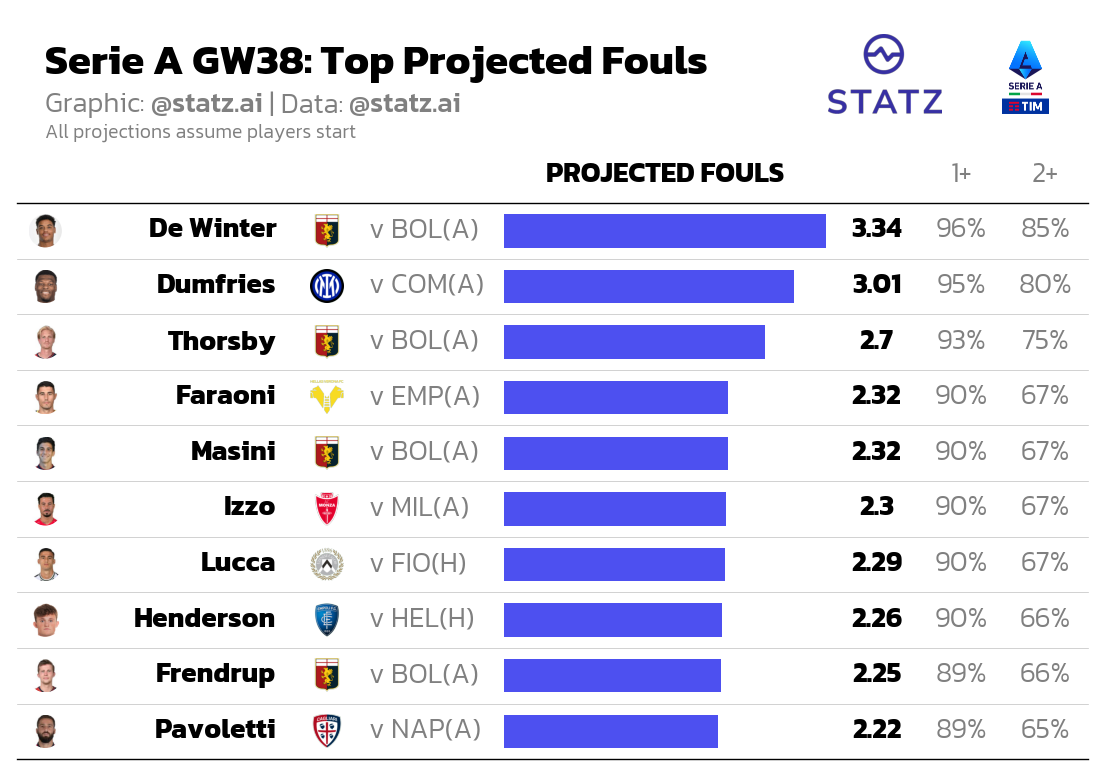

In [527]:
from PIL import Image
fig, ax = plt.subplots(figsize=(12 + len(percent_columns), 8))
fig.set_facecolor(bg_colour)
ax.set_facecolor(bg_colour)

table = Table(
    df_plot,
    column_definitions=col_defs,
    index_col="Player Image",
    row_dividers=True,
    row_divider_kw={"linewidth" : 0.5, "linestyle" : '-', "color" : "grey", "alpha" : 0.5},
    footer_divider=True,
    textprops={"fontsize" : 18},
    ax=ax,
)

import highlight_text

title = fig.add_axes([0.15,0.85,0.75,0.2])
title.set_facecolor(bg_colour)
title.axis("off")
title.text(0, 0.6, f"{league_short} {GW}: Top Projected {stat_name_shortened}", ha='left', fontsize=30, fontweight='bold', color=text_colour, fontproperties=bold)
highlight_text.fig_text(x=0.15, y=0.93, s=f"Graphic: <@statz.ai> | Data: <@statz.ai>",  highlight_textprops=[{"fontproperties":medium},{"fontproperties":medium}], fontsize=20, color="grey", va='center', ha='left', ax=title, fontproperties = light)
title.text(0, 0.2, "All projections assume players start", ha='left', fontsize=14, color='grey', fontproperties=light)
from skimage import io
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

home_logo = io.imread(f"C:/Users/George/Documents/Football Analytics/Images/{league}_logo.png")

home_logo_ax = OffsetImage(home_logo)
home_logo_ax = fig.add_axes([0.8, 0.92, 0.1, 0.1], zorder=1)
home_logo_ax.imshow(home_logo)
home_logo_ax.axis("off")

statz_logo = io.imread(r"C:\Users\George\Documents\Statz.ai\Images\Logos and Backgrounds\Statz Logo Purple PNG.png")

statz_logo_ax = OffsetImage(statz_logo)
statz_logo_ax = fig.add_axes([0.7, 0.92, 0.1, 0.1], zorder=1)
statz_logo_ax.imshow(statz_logo)
statz_logo_ax.axis("off")

In [528]:
projections.sort_values(stat, ascending=False).head(10)

,Player,Position,Team,Opponent,Venue,Start?,Goals,Assists,Shots Total,Shots On Target,Passes,Interceptions,Tackles,Total Crosses,Yellow Cards,Fouls,Fouls Drawn,Offsides,Saves
140,Koni De Winter,DEF,Genoa,Bologna,A,Yes,0.09,0.00,0.28,0.27,39.90,1.03,1.25,0.09,0.29,3.34,0.75,0.02,0.0
33,Denzel Dumfries,DEF,Inter,Como,A,Yes,0.17,0.13,1.03,0.40,23.89,0.40,1.79,2.67,0.28,3.01,0.93,0.12,0.0
125,Morten Thorsby,MID,Genoa,Bologna,A,Yes,0.00,0.04,0.39,0.13,18.25,0.10,1.50,0.31,0.42,2.70,0.90,0.51,0.0
296,Davide Faraoni,DEF,Hellas Verona,Empoli,A,No,0.00,0.00,0.08,0.02,13.41,0.25,1.96,2.32,0.07,2.32,0.17,0.46,0.0
144,Patrizio Masini,MID,Genoa,Bologna,A,Yes,0.04,0.00,0.20,0.03,19.28,0.55,1.84,0.59,0.12,2.32,1.66,0.00,0.0
187,Armando Izzo,DEF,Monza,Milan,A,No,0.06,0.02,0.15,0.04,42.01,1.22,1.41,0.17,0.53,2.30,1.66,0.00,0.0
440,Lorenzo Lucca,FWD,Udinese,Fiorentina,H,No,0.25,0.08,2.21,0.81,12.45,0.19,0.17,0.11,0.33,2.29,1.55,0.61,0.0
276,Liam Henderson,FWD,Empoli,Hellas Verona,H,No,0.00,0.17,0.82,0.09,35.46,0.36,0.82,3.42,0.25,2.26,0.97,0.10,0.0
138,Morten Frendrup,MID,Genoa,Bologna,A,Yes,0.04,0.00,0.63,0.22,27.84,1.15,2.18,0.03,0.18,2.25,1.01,0.05,0.0
79,Leonardo Pavoletti,FWD,Cagliari,Napoli,A,Yes,0.04,0.00,0.60,0.24,8.70,0.00,0.48,0.00,0.01,2.22,0.86,0.25,0.0


In [529]:
fig.savefig(rf"C:\Users\George\Documents\Statz.ai\Visuals\Top Projections\{league_short} {GW} {stat} (blue).png", bbox_inches='tight', facecolor=bg_colour, dpi=600)